<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/DualDecoder_UNet_REFUGE_withdim_384*384_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Decoder U-Net (Y-Net) — Parallel Disc & Cup Segmentation (REFUGE, 3-class)

**Architecture idea:** one *shared* U-Net encoder + bottleneck feeds **two parallel decoders**:

- **Pipeline 1 (disc head):** predicts **background vs disc** (disc = whole optic disc, i.e. disc+cup), `channels = 2`
- **Pipeline 2 (cup head):** predicts **background vs cup**, `channels = 2`

Both decoders run in parallel on the same features and are trained together (disc-loss + cup-loss).
Metrics for the **two pipelines are reported separately** for **train, validation, and test**.
Single-stage — the network sees the **full 256x256 fundus image** (no disc-guided cropping).


In [1]:
# ============================================================
# CELL 0 — Environment setup
# Installs libs, imports everything, fixes seeds for reproducibility,
# and selects GPU/CPU. Run once at the top.
# ============================================================
!pip install -q albumentations opencv-python-headless

import os, cv2, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy import ndimage

# --- reproducibility: fix all random seeds so runs are comparable ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 384                     # all images/masks resized to 256x256
print("Device:", DEVICE)

Device: cuda


In [2]:
# ============================================================
# CELL 1 — Kaggle authentication + dataset download
# Upload your kaggle.json (from your Kaggle account) when prompted,
# then this pulls the REFUGE glaucoma dataset and unzips it.
# ============================================================
from google.colab import files
print("Upload kaggle.json:")
files.upload()                                              # pick your kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [05:20<00:00, 18.6MB/s]



In [3]:
# ============================================================
# CELL 2 — Base REFUGE dataset (raw 3-class masks)
# Loads each fundus image + its mask. Mask pixel values:
#   0 = background, 1 = optic disc (rim), 2 = optic cup
# This base class returns the FULL 3-class mask; we split it into
# the two binary tasks in Cell 4.
# ============================================================
DATA_ROOT = "/content/data/REFUGE"

class REFUGEDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir, self.mask_dir, self.transform = img_dir, mask_dir, transform
        # keep only images that have a matching .png mask
        self.filenames = []
        for f in sorted(os.listdir(img_dir)):
            base = os.path.splitext(f)[0]
            mp = os.path.join(mask_dir, base + ".png")
            if os.path.exists(mp):
                self.filenames.append((f, base + ".png"))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        # read image as RGB, mask as-is (keeps 0/1/2 label values)
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']
        return image, mask.long()               # image: 3xHxW float tensor, mask: HxW long

In [4]:
# ============================================================
# CELL 3 — Augmentations + base datasets
# Train-time augmentation (flips/rotate/brightness) for robustness;
# val/test only resize + normalize. ImageNet normalization stats.
# ============================================================
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

# base (3-class) datasets for the three official REFUGE splits
train_ds = REFUGEDataset(f"{DATA_ROOT}/train/Images_Cropped", f"{DATA_ROOT}/train/Masks_Cropped", train_transform)
val_ds   = REFUGEDataset(f"{DATA_ROOT}/val/Images_Cropped",   f"{DATA_ROOT}/val/Masks_Cropped",   val_transform)
test_ds  = REFUGEDataset(f"{DATA_ROOT}/test/Images_Cropped",  f"{DATA_ROOT}/test/Masks_Cropped",  val_transform)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 400 Val: 400 Test: 400


In [5]:
# ============================================================
# CELL 4 — Dual-task wrapper: split the 3-class mask into TWO binary masks
# For every sample we return:
#   image   : 3xHxW
#   disc_m  : HxW  -> 1 where (mask > 0)  == whole optic disc (disc + cup)   [Pipeline 1 target]
#   cup_m   : HxW  -> 1 where (mask == 2) == optic cup only                  [Pipeline 2 target]
# Both decoders are trained from these two independent binary labels.
# ============================================================
class DualTaskDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        image, mask3 = self.base[idx]
        disc_m = (mask3 > 0).long()     # background vs DISC (disc+cup)
        cup_m  = (mask3 == 2).long()    # background vs CUP
        return image, disc_m, cup_m

train_ds_dual = DualTaskDataset(train_ds)
val_ds_dual   = DualTaskDataset(val_ds)
test_ds_dual  = DualTaskDataset(test_ds)
# 384 -> batch_size=4     |     512 -> batch_size=2   (if 512 OOMs, use 1)
train_loader = DataLoader(train_ds_dual, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds_dual,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds_dual,  batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

# sanity check: shapes + label values of one batch
imgs, disc_m, cup_m = next(iter(train_loader))
print("img:", imgs.shape, "| disc:", disc_m.shape, torch.unique(disc_m).tolist(),
      "| cup:", cup_m.shape, torch.unique(cup_m).tolist())

img: torch.Size([4, 3, 384, 384]) | disc: torch.Size([4, 384, 384]) [0, 1] | cup: torch.Size([4, 384, 384]) [0, 1]


In [6]:
# ============================================================
# CELL 5 — Metrics (per binary head) + dual evaluation helper
# compute_all_metrics: Dice/IoU/Precision/Recall/F1 per class (0=bg, 1=fg) + accuracy
# evaluate_dual: runs the model once and returns SEPARATE metric dicts
#                for the disc pipeline and the cup pipeline.
# ============================================================
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes=2, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    m = {k: [] for k in ["dice","iou","precision","recall","f1"]}
    for c in range(num_classes):
        pred_c, target_c = (preds == c), (targets == c)
        tp = (pred_c & target_c).sum().float()
        fp = (pred_c & ~target_c).sum().float()
        fn = (~pred_c & target_c).sum().float()
        precision = (tp+smooth)/(tp+fp+smooth)
        recall    = (tp+smooth)/(tp+fn+smooth)
        m["dice"].append(((2*tp+smooth)/(2*tp+fp+fn+smooth)).item())
        m["iou"].append(((tp+smooth)/(tp+fp+fn+smooth)).item())
        m["precision"].append(precision.item())
        m["recall"].append(recall.item())
        m["f1"].append(((2*precision*recall)/(precision+recall+smooth)).item())
    m["accuracy"] = (preds == targets).float().mean().item()
    return m

@torch.no_grad()
def evaluate_dual(model, loader, criterion, device=DEVICE):
    """Return (avg_loss, disc_metrics, cup_metrics) — the two pipelines scored separately."""
    model.eval()
    running_loss = 0.0
    keys = ["dice","iou","precision","recall","f1"]
    agg_disc = {k: np.zeros(2) for k in keys}; agg_disc["accuracy"] = 0.0
    agg_cup  = {k: np.zeros(2) for k in keys}; agg_cup["accuracy"]  = 0.0
    n_batches = 0
    for imgs, disc_m, cup_m in loader:
        imgs, disc_m, cup_m = imgs.to(device), disc_m.to(device), cup_m.to(device)
        out_disc, out_cup = model(imgs)                      # two heads
        # total loss = disc loss + cup loss (for reporting)
        running_loss += (criterion(out_disc, disc_m) + criterion(out_cup, cup_m)).item() * imgs.size(0)
        md_ = compute_all_metrics(out_disc, disc_m)          # disc pipeline metrics
        mc_ = compute_all_metrics(out_cup,  cup_m)           # cup  pipeline metrics
        for k in keys:
            agg_disc[k] += np.array(md_[k]); agg_cup[k] += np.array(mc_[k])
        agg_disc["accuracy"] += md_["accuracy"]; agg_cup["accuracy"] += mc_["accuracy"]
        n_batches += 1
    for k in keys:
        agg_disc[k] /= n_batches; agg_cup[k] /= n_batches
    agg_disc["accuracy"] /= n_batches; agg_cup["accuracy"] /= n_batches
    return running_loss/len(loader.dataset), agg_disc, agg_cup

In [7]:
# ============================================================
# CELL 6 — Losses
# DiceLoss: soft multi-class Dice. CombinedLoss: 0.5*CE + 0.5*Dice.
# Each head is a 2-class problem, so we instantiate with num_classes=2.
# ============================================================
class DiceLoss(nn.Module):
    def __init__(self, num_classes=2, smooth=1e-6):
        super().__init__()
        self.num_classes, self.smooth = num_classes, smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        inter = torch.sum(probs*targets_oh, (0,2,3))
        union = torch.sum(probs+targets_oh, (0,2,3))
        return 1 - ((2*inter+self.smooth)/(union+self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

In [10]:
# ============================================================
# CELL 7 — Dual-Decoder U-Net (Y-Net)
# ONE shared encoder + bottleneck  -->  TWO parallel U-Net decoders.
#   * DoubleConv : the standard (conv-bn-relu) x2 block
#   * Decoder    : one full U-Net decoder branch (uses the shared encoder skips)
#   * DualDecoderUNet : shared encoder + disc_decoder + cup_decoder
# forward() returns (disc_logits, cup_logits), each of shape B x 2 x H x W.
# ============================================================
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU) x2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class Decoder(nn.Module):
    """One U-Net decoder branch: 4 up-sampling steps, each concatenating the
       matching shared-encoder skip feature, then a 1x1 head to `num_classes`."""
    def __init__(self, base_ch=64, num_classes=2):
        super().__init__()
        C1, C2, C3, C4 = base_ch, base_ch*2, base_ch*4, base_ch*8
        self.up4 = nn.ConvTranspose2d(C4*2, C4, 2, stride=2); self.dec4 = DoubleConv(C4*2, C4)
        self.up3 = nn.ConvTranspose2d(C4,   C3, 2, stride=2); self.dec3 = DoubleConv(C3*2, C3)
        self.up2 = nn.ConvTranspose2d(C3,   C2, 2, stride=2); self.dec2 = DoubleConv(C2*2, C2)
        self.up1 = nn.ConvTranspose2d(C2,   C1, 2, stride=2); self.dec1 = DoubleConv(C1*2, C1)
        self.head = nn.Conv2d(C1, num_classes, 1)
    def forward(self, b, e1, e2, e3, e4):
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))     # skip from enc4
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))     # skip from enc3
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))     # skip from enc2
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))     # skip from enc1
        return self.head(d1)

class DualDecoderUNet(nn.Module):
    """Shared encoder/bottleneck + two independent decoders running in parallel."""
    def __init__(self, in_ch=3, base_ch=64, num_classes=2):
        super().__init__()
        C1, C2, C3, C4 = base_ch, base_ch*2, base_ch*4, base_ch*8
        # ---- shared encoder (same as the first half of a plain U-Net) ----
        self.enc1 = DoubleConv(in_ch, C1)
        self.enc2 = DoubleConv(C1, C2)
        self.enc3 = DoubleConv(C2, C3)
        self.enc4 = DoubleConv(C3, C4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(C4, C4*2)
        # ---- two parallel decoder heads ----
        self.disc_decoder = Decoder(base_ch, num_classes)    # Pipeline 1: bg vs disc
        self.cup_decoder  = Decoder(base_ch, num_classes)    # Pipeline 2: bg vs cup
    def forward(self, x):
        e1 = self.enc1(x)                 # full-res features
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))                  # shared bottleneck
        disc_logits = self.disc_decoder(b, e1, e2, e3, e4)   # decoder 1 (parallel)
        cup_logits  = self.cup_decoder (b, e1, e2, e3, e4)   # decoder 2 (parallel)
        return disc_logits, cup_logits

# sanity check: forward a dummy batch, print output shapes + parameter count
_m = DualDecoderUNet().to(DEVICE)
_od, _oc = _m(torch.randn(2,3,384,384).to(DEVICE))
print("disc head:", _od.shape, "| cup head:", _oc.shape)
print("params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
del _m, _od, _oc

disc head: torch.Size([2, 2, 384, 384]) | cup head: torch.Size([2, 2, 384, 384])
params: 43236036


In [11]:
# ============================================================
# CELL 8 — Training loop (dual head)
# Loss per step = disc_loss + cup_loss (both CE+Dice).
# Every epoch we print the Dice of BOTH pipelines SEPARATELY, for BOTH
# the training set and the validation set, clearly labelled:
#     DISC head -> [bg, disc]      CUP head -> [bg, cup]
# Best checkpoint = highest mean foreground Dice = (disc_fg + cup_fg)/2 on val.
# ============================================================
def train_dual(model, train_loader, val_loader,
               num_epochs=150, patience=25, lr=1e-3,
               save_path="/content/best_dualunet.pth"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = CombinedLoss(2)

    # history keeps per-class Dice for train & val, for both heads, for plotting
    history = {"train_loss": [], "val_loss": []}
    for split in ["train","val"]:
        for head in ["disc","cup"]:
            for c in range(2):
                history[f"{split}_{head}_dice_c{c}"] = []
    history["val_mean_fg"] = []

    best_mean, no_improve = 0.0, 0
    print("="*70, "\nTraining Dual-Decoder U-Net (disc + cup in parallel)\n", "="*70, sep="")
    for epoch in range(1, num_epochs+1):
        # ---------- train one epoch ----------
        model.train()
        running = 0.0
        for imgs, disc_m, cup_m in train_loader:
            imgs, disc_m, cup_m = imgs.to(DEVICE), disc_m.to(DEVICE), cup_m.to(DEVICE)
            optimizer.zero_grad()
            out_disc, out_cup = model(imgs)
            loss = criterion(out_disc, disc_m) + criterion(out_cup, cup_m)   # joint loss
            loss.backward(); optimizer.step()
            running += loss.item() * imgs.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---------- evaluate on train + val (both heads separately) ----------
        _,        tr_disc, tr_cup = evaluate_dual(model, train_loader, criterion)
        val_loss, va_disc, va_cup = evaluate_dual(model, val_loader,   criterion)
        scheduler.step()

        # ---------- log history ----------
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        for c in range(2):
            history[f"train_disc_dice_c{c}"].append(tr_disc["dice"][c])
            history[f"train_cup_dice_c{c}"].append(tr_cup["dice"][c])
            history[f"val_disc_dice_c{c}"].append(va_disc["dice"][c])
            history[f"val_cup_dice_c{c}"].append(va_cup["dice"][c])
        mean_fg = (va_disc["dice"][1] + va_cup["dice"][1]) / 2   # selection metric
        history["val_mean_fg"].append(mean_fg)

        # ---------- print (both pipelines, train + val, clearly labelled) ----------
        print(f"Ep {epoch:3d}/{num_epochs} | TrLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | ValMeanFG:{mean_fg:.4f}")
        print(f"   DISC head [bg, disc] -> Train Dice:{np.round(tr_disc['dice'],3)} | Val Dice:{np.round(va_disc['dice'],3)}")
        print(f"   CUP  head [bg, cup ] -> Train Dice:{np.round(tr_cup['dice'],3)} | Val Dice:{np.round(va_cup['dice'],3)}")

        # ---------- checkpoint on best val mean-foreground Dice ----------
        if mean_fg > best_mean:
            best_mean, no_improve = mean_fg, 0
            torch.save(model.state_dict(), save_path)
            print(f"   -> best saved (mean FG Dice = {best_mean:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    return history

In [12]:
# ============================================================
# CELL 9 — Build the model and train it
# ============================================================
model = DualDecoderUNet(in_ch=3, base_ch=64, num_classes=2).to(DEVICE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

history = train_dual(model, train_loader, val_loader,
                     num_epochs=150, patience=25, lr=1e-3,
                     save_path="/content/best_dualunet.pth")

Trainable params: 43236036
Training Dual-Decoder U-Net (disc + cup in parallel)
Ep   1/150 | TrLoss:0.5805 | ValLoss:1.3840 | ValMeanFG:0.6327
   DISC head [bg, disc] -> Train Dice:[0.788 0.919] | Val Dice:[0.333 0.834]
   CUP  head [bg, cup ] -> Train Dice:[0.903 0.606] | Val Dice:[0.642 0.431]
   -> best saved (mean FG Dice = 0.6327)
Ep   2/150 | TrLoss:0.4614 | ValLoss:1.6945 | ValMeanFG:0.6100
   DISC head [bg, disc] -> Train Dice:[0.843 0.927] | Val Dice:[0.434 0.845]
   CUP  head [bg, cup ] -> Train Dice:[0.92  0.694] | Val Dice:[0.49  0.375]
Ep   3/150 | TrLoss:0.4168 | ValLoss:1.8106 | ValMeanFG:0.6242
   DISC head [bg, disc] -> Train Dice:[0.836 0.93 ] | Val Dice:[0.502 0.853]
   CUP  head [bg, cup ] -> Train Dice:[0.914 0.691] | Val Dice:[0.553 0.396]
Ep   4/150 | TrLoss:0.3835 | ValLoss:0.7030 | ValMeanFG:0.7675
   DISC head [bg, disc] -> Train Dice:[0.846 0.936] | Val Dice:[0.762 0.903]
   CUP  head [bg, cup ] -> Train Dice:[0.943 0.734] | Val Dice:[0.887 0.632]
   -> best 

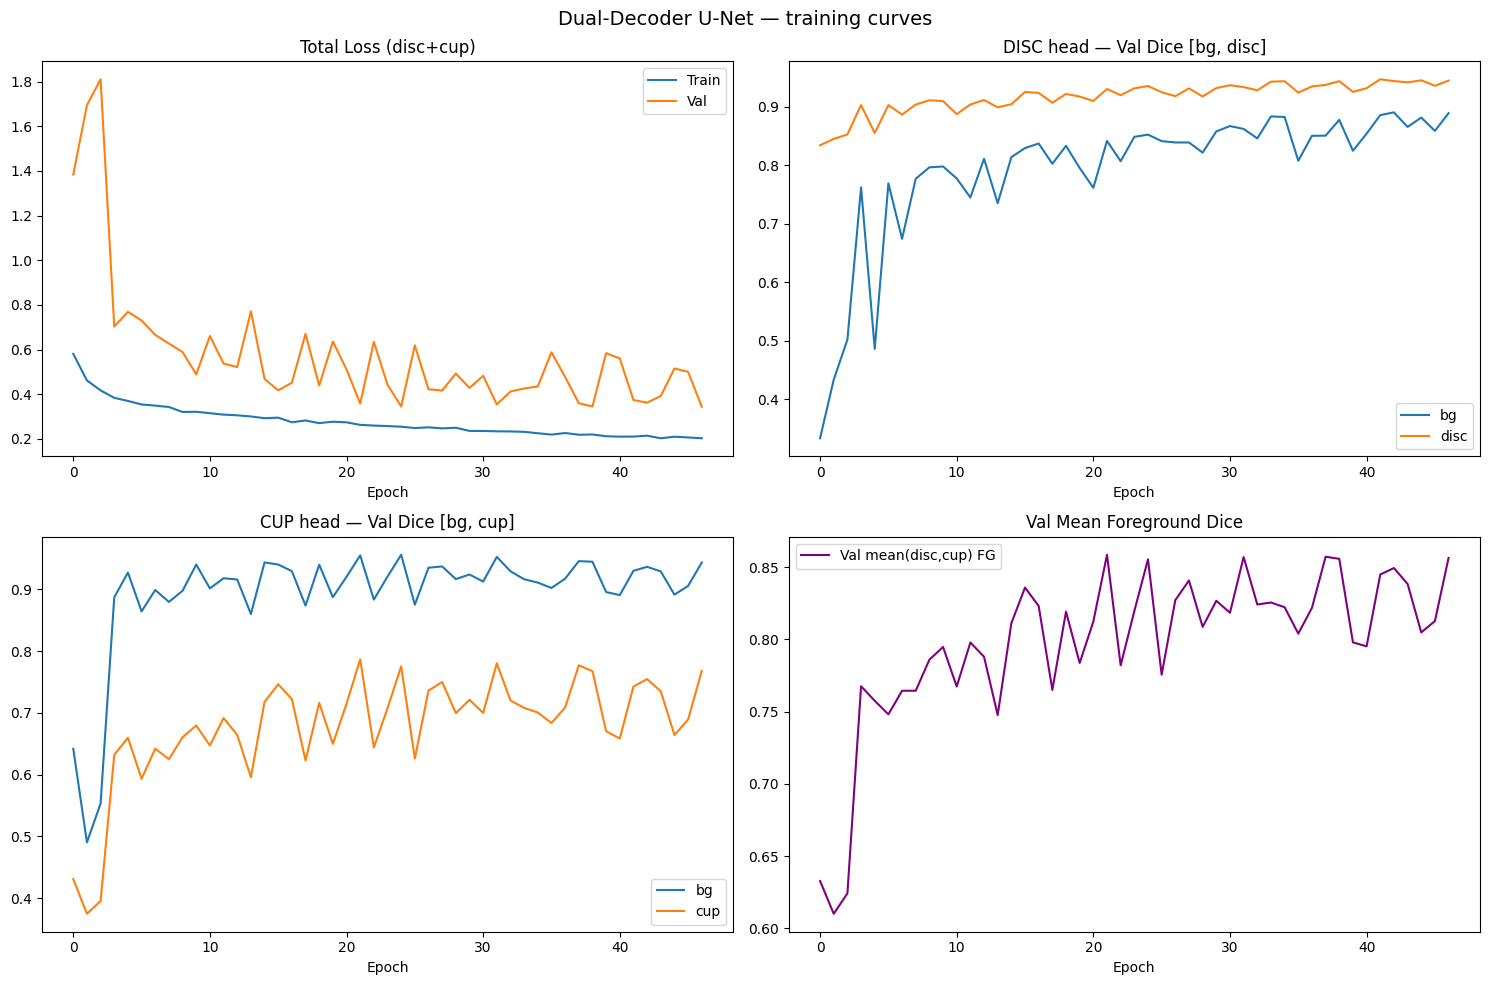

In [13]:
# ============================================================
# CELL 10 — Training curves (both pipelines separately)
# ============================================================
def plot_dual_curves(history):
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Dual-Decoder U-Net — training curves", fontsize=14)

    # (0,0) loss
    ax[0,0].plot(history["train_loss"], label="Train")
    ax[0,0].plot(history["val_loss"],   label="Val")
    ax[0,0].set_title("Total Loss (disc+cup)"); ax[0,0].legend(); ax[0,0].set_xlabel("Epoch")

    # (0,1) DISC pipeline dice (bg, disc)
    ax[0,1].plot(history["val_disc_dice_c0"], label="bg")
    ax[0,1].plot(history["val_disc_dice_c1"], label="disc")
    ax[0,1].set_title("DISC head — Val Dice [bg, disc]"); ax[0,1].legend(); ax[0,1].set_xlabel("Epoch")

    # (1,0) CUP pipeline dice (bg, cup)
    ax[1,0].plot(history["val_cup_dice_c0"], label="bg")
    ax[1,0].plot(history["val_cup_dice_c1"], label="cup")
    ax[1,0].set_title("CUP head — Val Dice [bg, cup]"); ax[1,0].legend(); ax[1,0].set_xlabel("Epoch")

    # (1,1) mean foreground dice train vs val
    ax[1,1].plot(history["val_mean_fg"], color="purple", label="Val mean(disc,cup) FG")
    ax[1,1].set_title("Val Mean Foreground Dice"); ax[1,1].legend(); ax[1,1].set_xlabel("Epoch")

    plt.tight_layout(); plt.savefig("/content/dualunet_curves.png", dpi=100); plt.show()

plot_dual_curves(history)

In [14]:
# ============================================================
# CELL 11 — TEST-set evaluation (the two pipelines reported SEPARATELY)
# Loads the best checkpoint and prints full metrics for:
#   * DISC pipeline -> classes are [bg, disc]
#   * CUP  pipeline -> classes are [bg, cup]
# ============================================================
model.load_state_dict(torch.load("/content/best_dualunet.pth")); model.eval()
criterion = CombinedLoss(2)

test_loss, test_disc, test_cup = evaluate_dual(model, test_loader, criterion)

def print_pipeline(name, fg_label, m):
    print("="*55)
    print(f"{name} PIPELINE — TEST RESULTS   (classes: bg, {fg_label})")
    print("="*55)
    print(f"Accuracy : {m['accuracy']:.4f}")
    print(f"Dice     -> bg:{m['dice'][0]:.4f} | {fg_label}:{m['dice'][1]:.4f}")
    print(f"IoU      -> bg:{m['iou'][0]:.4f} | {fg_label}:{m['iou'][1]:.4f}")
    print(f"Precision-> bg:{m['precision'][0]:.4f} | {fg_label}:{m['precision'][1]:.4f}")
    print(f"Recall   -> bg:{m['recall'][0]:.4f} | {fg_label}:{m['recall'][1]:.4f}")
    print(f"F1       -> bg:{m['f1'][0]:.4f} | {fg_label}:{m['f1'][1]:.4f}")

print(f"Test total loss (disc+cup): {test_loss:.4f}\n")
print_pipeline("DISC", "disc", test_disc)
print()
print_pipeline("CUP",  "cup",  test_cup)

Test total loss (disc+cup): 0.3791

DISC PIPELINE — TEST RESULTS   (classes: bg, disc)
Accuracy : 0.8971
Dice     -> bg:0.8316 | disc:0.9257
IoU      -> bg:0.7135 | disc:0.8623
Precision-> bg:0.9355 | disc:0.8832
Recall   -> bg:0.7514 | disc:0.9735
F1       -> bg:0.8316 | disc:0.9257

CUP PIPELINE — TEST RESULTS   (classes: bg, cup)
Accuracy : 0.9217
Dice     -> bg:0.9514 | cup:0.7906
IoU      -> bg:0.9076 | cup:0.6566
Precision-> bg:0.9729 | cup:0.7282
Recall   -> bg:0.9315 | cup:0.8786
F1       -> bg:0.9514 | cup:0.7906


In [15]:
# ============================================================
# CELL 12 — (Optional) Fuse the two heads into ONE 3-class map
# Only for the project's "mean disc+cup" target. NOT used in training.
# Rule: start from disc prediction; wherever BOTH disc AND cup fire, label = cup.
#   final: 0=bg, 1=disc(rim), 2=cup   (cup forced to lie inside disc)
# ============================================================
@torch.no_grad()
def evaluate_fused_3class(model, dataset, smooth=1e-6):
    model.eval()
    names = ["Background","Disc(rim)","Cup"]
    agg = {k: np.zeros(3) for k in ["dice","iou","precision","recall","f1"]}; agg["accuracy"]=0.0
    for i in range(len(dataset)):
        image, mask3 = dataset[i]                              # base 3-class gt (0/1/2)
        out_disc, out_cup = model(image.unsqueeze(0).to(DEVICE))
        disc_p = torch.argmax(out_disc, 1)[0].cpu().numpy()    # 0/1 (whole disc)
        cup_p  = torch.argmax(out_cup,  1)[0].cpu().numpy()    # 0/1 (cup)
        final = disc_p.copy().astype(np.uint8)                 # disc -> 1
        final[(cup_p==1) & (disc_p==1)] = 2                    # cup inside disc -> 2
        gt = mask3.numpy()
        for c in range(3):
            pc, gc = (final==c), (gt==c)
            tp=(pc&gc).sum(); fp=(pc&~gc).sum(); fn=(~pc&gc).sum()
            prec=(tp+smooth)/(tp+fp+smooth); rec=(tp+smooth)/(tp+fn+smooth)
            agg["dice"][c]      += (2*tp+smooth)/(2*tp+fp+fn+smooth)
            agg["iou"][c]       += (tp+smooth)/(tp+fp+fn+smooth)
            agg["precision"][c] += prec; agg["recall"][c] += rec
            agg["f1"][c]        += (2*prec*rec)/(prec+rec+smooth)
        agg["accuracy"] += (final==gt).mean()
    for k in agg: agg[k] = agg[k]/len(dataset)
    print("="*60); print("FUSED 3-CLASS TEST RESULTS"); print("="*60)
    print(f"Accuracy: {agg['accuracy']:.4f}")
    for k in ["dice","iou","precision","recall","f1"]:
        print(f"{k.upper():10s}: " + "  |  ".join(f"{names[c]}: {agg[k][c]:.4f}" for c in range(3)))
    print(f"\nMean Disc+Cup Dice: {(agg['dice'][1]+agg['dice'][2])/2:.4f}")
    return agg

fused_metrics = evaluate_fused_3class(model, test_ds)

FUSED 3-CLASS TEST RESULTS
Accuracy: 0.8212
DICE      : Background: 0.8317  |  Disc(rim): 0.8192  |  Cup: 0.7817
IOU       : Background: 0.7194  |  Disc(rim): 0.7017  |  Cup: 0.6551
PRECISION : Background: 0.9365  |  Disc(rim): 0.7982  |  Cup: 0.7403
RECALL    : Background: 0.7610  |  Disc(rim): 0.8497  |  Cup: 0.8861
F1        : Background: 0.8317  |  Disc(rim): 0.8192  |  Cup: 0.7817

Mean Disc+Cup Dice: 0.8005


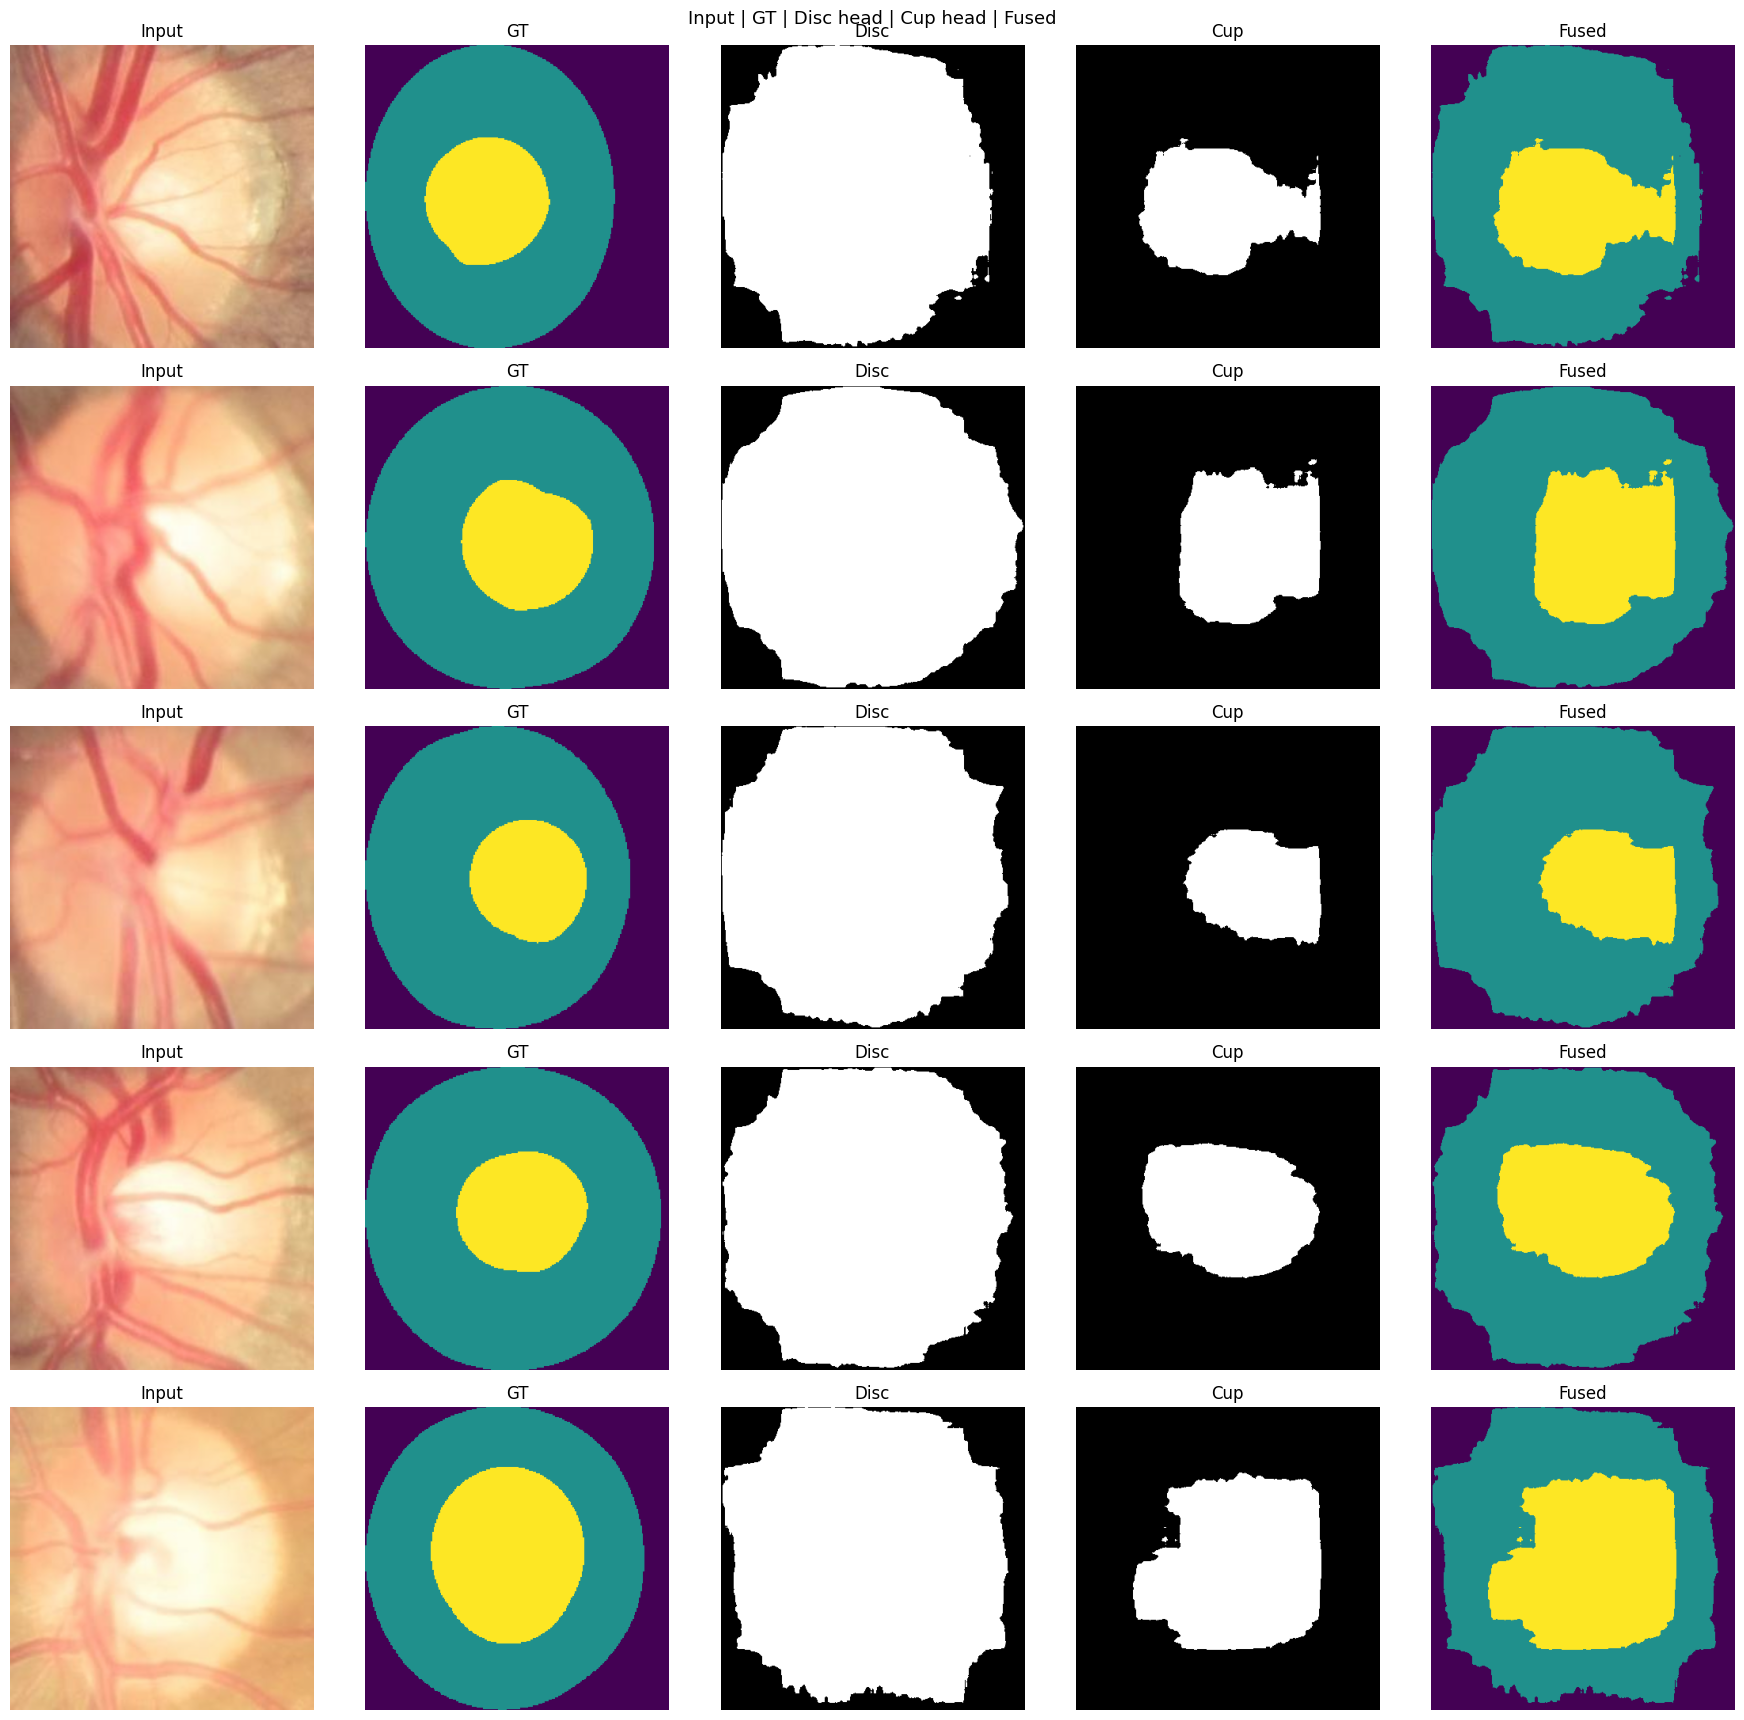

In [17]:
# ============================================================
# CELL 13 — Visualize predictions
# Columns: input | GT (3-class) | disc head | cup head | fused 3-class
# ============================================================
MEAN = np.array([0.485,0.456,0.406]); STD = np.array([0.229,0.224,0.225])

@torch.no_grad()
def visualize(dataset, n=5):
    model.eval()
    idxs = random.sample(range(len(dataset)), n)
    fig, ax = plt.subplots(n, 5, figsize=(18, 3.5*n))
    fig.suptitle("Input | GT | Disc head | Cup head | Fused", fontsize=13)
    for r, idx in enumerate(idxs):
        image, mask3 = dataset[idx]
        out_disc, out_cup = model(image.unsqueeze(0).to(DEVICE))
        disc_p = torch.argmax(out_disc,1)[0].cpu().numpy()
        cup_p  = torch.argmax(out_cup, 1)[0].cpu().numpy()
        fused  = disc_p.copy().astype(np.uint8); fused[(cup_p==1)&(disc_p==1)] = 2
        img_show = (image.permute(1,2,0).cpu().numpy()*STD + MEAN).clip(0,1)
        for c,(im,ttl,kw) in enumerate([
            (img_show,"Input",{}),
            (mask3.numpy(),"GT",{"cmap":"viridis","vmin":0,"vmax":2}),
            (disc_p,"Disc",{"cmap":"gray","vmin":0,"vmax":1}),
            (cup_p,"Cup",{"cmap":"gray","vmin":0,"vmax":1}),
            (fused,"Fused",{"cmap":"viridis","vmin":0,"vmax":2})]):
            ax[r,c].imshow(im, **kw); ax[r,c].set_title(ttl); ax[r,c].axis("off")
    plt.tight_layout(); plt.savefig("/content/dualunet_predictions.png", dpi=100); plt.show()

visualize(test_ds, n=5)

In [18]:
# ============================================================
# CELL 14 — FULL RUN SUMMARY (everything in one place)
# Param count · input dimension · best TRAIN & VAL Dice (both pipelines)
# · best mean-FG · best-checkpoint epoch · TEST metrics (disc & cup)
# · FUSED 3-class (rim, cup) on test — using CELL 13's fusion rule.
# ============================================================
import numpy as np, torch

model.load_state_dict(torch.load("/content/best_dualunet.pth")); model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# ---- bests from history ----
val_mean  = history["val_mean_fg"]
best_ep   = int(np.argmax(val_mean))              # epoch of best mean-FG (the saved ckpt)
best_mean = val_mean[best_ep]
peak_val_disc = max(history["val_disc_dice_c1"]);  peak_val_cup = max(history["val_cup_dice_c1"])
peak_tr_disc  = max(history["train_disc_dice_c1"]); peak_tr_cup = max(history["train_cup_dice_c1"])
ckpt_val_disc = history["val_disc_dice_c1"][best_ep];  ckpt_val_cup = history["val_cup_dice_c1"][best_ep]
ckpt_tr_disc  = history["train_disc_dice_c1"][best_ep]; ckpt_tr_cup = history["train_cup_dice_c1"][best_ep]

# ---- TEST (same evaluate_dual as CELL 11) ----
criterion = CombinedLoss(2)
test_loss, test_disc, test_cup = evaluate_dual(model, test_loader, criterion)
test_mean_fg = (test_disc["dice"][1] + test_cup["dice"][1]) / 2

# ---- FUSED 3-class on test (rim=1, cup=2) — SAME fusion as CELL 13 ----
@torch.no_grad()
def fused_test_dice(dataset, smooth=1e-6):
    tp = np.zeros(3); fp = np.zeros(3); fn = np.zeros(3)
    for i in range(len(dataset)):
        image, mask3 = dataset[i]                          # 0=bg, 1=disc/rim, 2=cup
        out_disc, out_cup = model(image.unsqueeze(0).to(DEVICE))
        disc_p = torch.argmax(out_disc, 1)[0].cpu().numpy()
        cup_p  = torch.argmax(out_cup,  1)[0].cpu().numpy()
        fused  = disc_p.copy().astype(np.uint8)
        fused[(cup_p == 1) & (disc_p == 1)] = 2            # cup ⊆ disc  (CELL 13 rule)
        gt = mask3.numpy()
        for c in range(3):
            p, g = (fused == c), (gt == c)
            tp[c] += np.logical_and(p, g).sum()
            fp[c] += np.logical_and(p, ~g).sum()
            fn[c] += np.logical_and(~p, g).sum()
    return (2*tp + smooth) / (2*tp + fp + fn + smooth)      # [bg, rim, cup]

fused = fused_test_dice(test_ds)
fused_rim, fused_cup = fused[1], fused[2]; fused_mean = (fused_rim + fused_cup) / 2

# ---------------- PRINT ----------------
print("="*60)
print("  DUAL-DECODER U-NET (Y-Net) — FULL RUN SUMMARY")
print(f"  Input dimension : {IMG_SIZE} x {IMG_SIZE}")
print(f"  Trainable params: {n_params:,}")
print(f"  Best checkpoint : epoch {best_ep+1}  (selected on val mean-FG)")
print("="*60)
print("  BEST VALIDATION Dice (foreground)")
print(f"    DISC pipeline  : peak {peak_val_disc:.4f}  | @best-ckpt {ckpt_val_disc:.4f}")
print(f"    CUP  pipeline  : peak {peak_val_cup:.4f}  | @best-ckpt {ckpt_val_cup:.4f}")
print(f"    MEAN(disc,cup) : best {best_mean:.4f}")
print("-"*60)
print("  BEST TRAIN Dice (foreground)")
print(f"    DISC pipeline  : peak {peak_tr_disc:.4f}  | @best-ckpt {ckpt_tr_disc:.4f}")
print(f"    CUP  pipeline  : peak {peak_tr_cup:.4f}  | @best-ckpt {ckpt_tr_cup:.4f}")
print("-"*60)
print("  TEST (best checkpoint) — pipelines reported SEPARATELY")
print(f"    DISC : Dice {test_disc['dice'][1]:.4f} | IoU {test_disc['iou'][1]:.4f} | P {test_disc['precision'][1]:.4f} | R {test_disc['recall'][1]:.4f}")
print(f"    CUP  : Dice {test_cup['dice'][1]:.4f} | IoU {test_cup['iou'][1]:.4f} | P {test_cup['precision'][1]:.4f} | R {test_cup['recall'][1]:.4f}")
print(f"    MEAN(disc,cup) Dice : {test_mean_fg:.4f}")
print("-"*60)
print("  TEST — FUSED 3-class (cup \u2286 disc):  rim=1, cup=2")
print(f"    Rim  Dice          : {fused_rim:.4f}")
print(f"    Cup  Dice          : {fused_cup:.4f}")
print(f"    MEAN(rim,cup) Dice : {fused_mean:.4f}")
print("="*60)

  DUAL-DECODER U-NET (Y-Net) — FULL RUN SUMMARY
  Input dimension : 384 x 384
  Trainable params: 43,236,036
  Best checkpoint : epoch 22  (selected on val mean-FG)
  BEST VALIDATION Dice (foreground)
    DISC pipeline  : peak 0.9471  | @best-ckpt 0.9305
    CUP  pipeline  : peak 0.7865  | @best-ckpt 0.7865
    MEAN(disc,cup) : best 0.8585
------------------------------------------------------------
  BEST TRAIN Dice (foreground)
    DISC pipeline  : peak 0.9707  | @best-ckpt 0.9530
    CUP  pipeline  : peak 0.8554  | @best-ckpt 0.7985
------------------------------------------------------------
  TEST (best checkpoint) — pipelines reported SEPARATELY
    DISC : Dice 0.9257 | IoU 0.8623 | P 0.8832 | R 0.9735
    CUP  : Dice 0.7906 | IoU 0.6566 | P 0.7282 | R 0.8786
    MEAN(disc,cup) Dice : 0.8582
------------------------------------------------------------
  TEST — FUSED 3-class (cup ⊆ disc):  rim=1, cup=2
    Rim  Dice          : 0.8257
    Cup  Dice          : 0.7929
    MEAN(rim,cu